<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d sharmagayatri/data-science-job-csv

Dataset URL: https://www.kaggle.com/datasets/sharmagayatri/data-science-job-csv
License(s): other
100% 247k/247k [00:00<00:00, 119MB/s]



In [2]:
import zipfile
with zipfile.ZipFile('data-science-job-csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [5]:
df.shape

(19158, 13)

In [6]:
col=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
len(df[col].dropna())/len(df)

0.8968577095730244

In [10]:
new_df=df[col].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

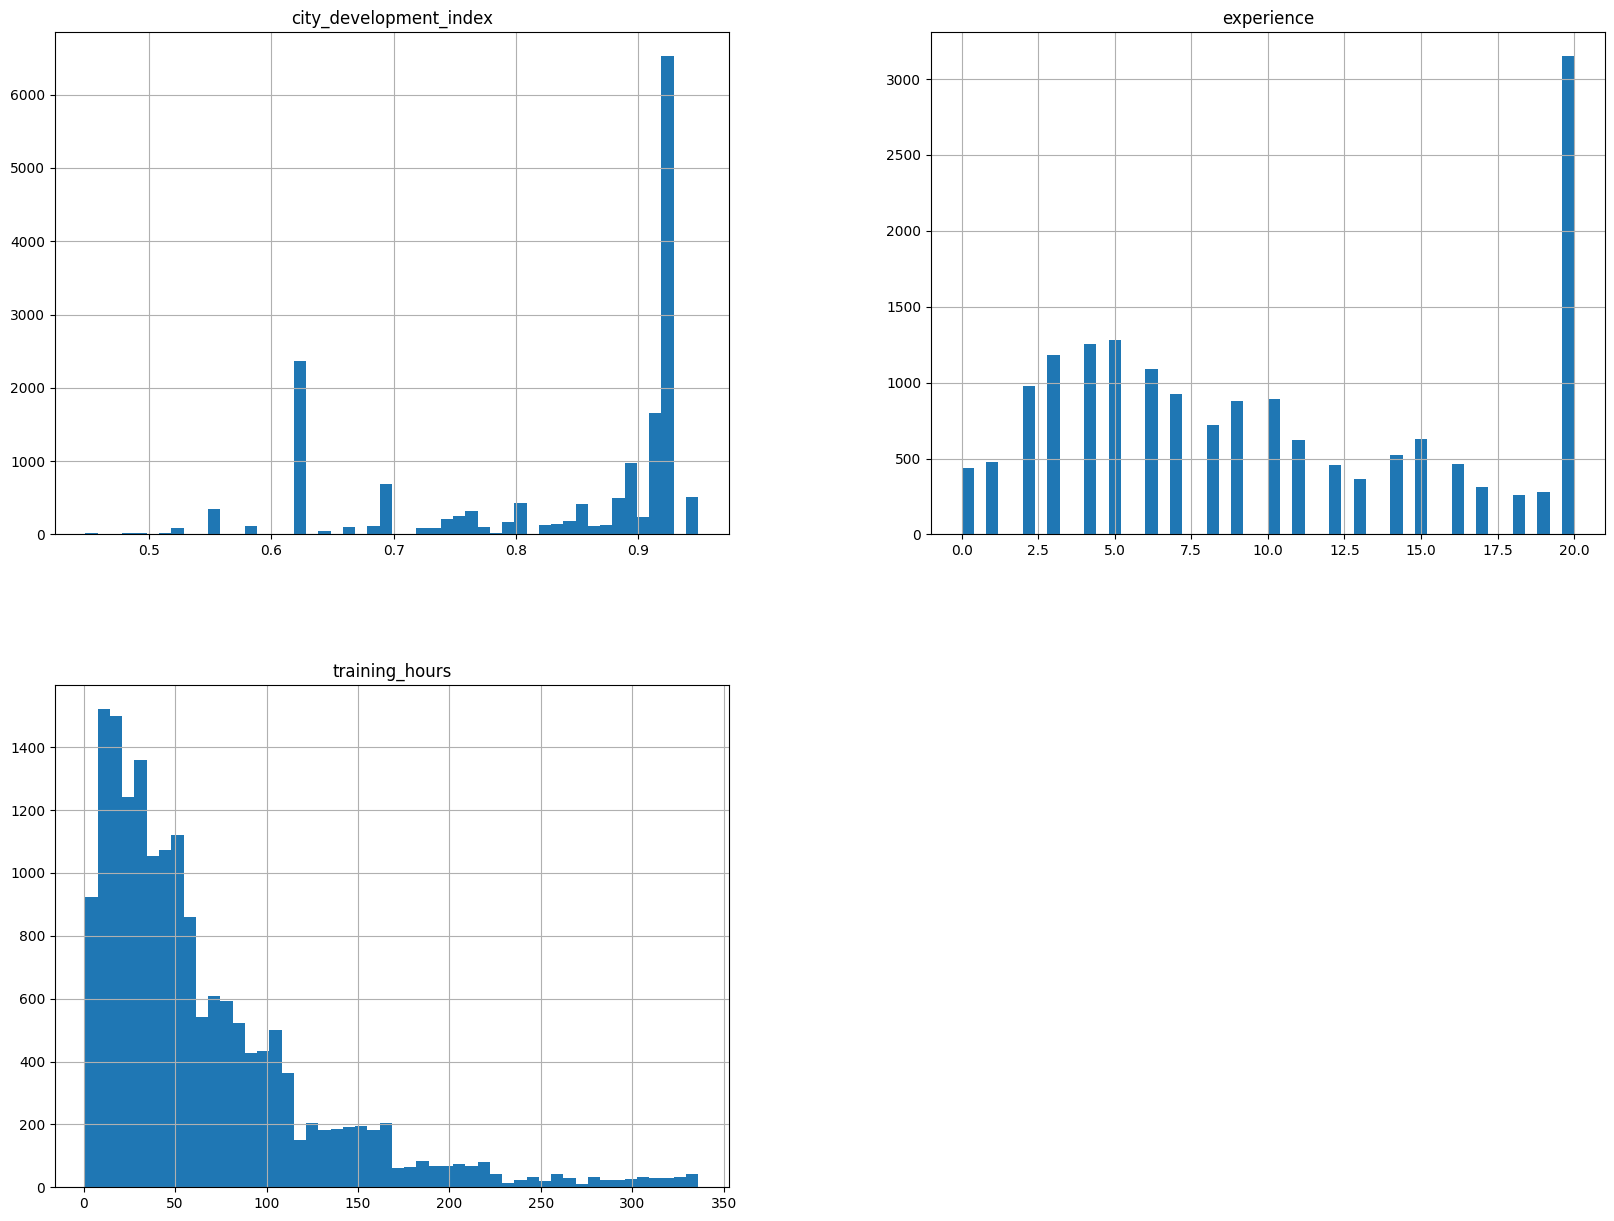

In [11]:
new_df.hist(bins=50,figsize=(20,15))
plt.show()

In [14]:
temp=pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)
temp.columns=['All','New']
temp


,All,New
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [16]:
temp=pd.concat([
    df['education_level'].value_counts()/len(df),
    new_df['education_level'].value_counts()/len(new_df)
],axis=1)
temp.columns=['All','New']
temp

,All,New
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
